# **Trading Strategy Backtest**

imports

In [ ]:
# general 
import pandas as pd 
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import plotly.graph_objects as px
import pickle
# ml 
import torch 
# custom modules
from data.kaggle_data import kaggle_price_return_data
from data.features_and_labels import rolling_volatility
import trading_logic.coinbase_order_functions as cb_trade
import models.lstm_trading as lstm
# coinbase 
from coinbase.rest import RESTClient

## **Offline Model Train/Evaluation/Test Pipeline**

### **Features**

In [2]:
"""
# portfolio assets and benchamrk
tickers = ['BTC-GBP', 
           'ETH-GBP', 
           'SOL-GBP', 
           'LINK-GBP', 
           'ADA-GBP',
           'ICP-GBP', 
           'CRV-GBP', 
           'UNI-GBP', 
           'USDT-GBP', 
           'ATOM-GBP', 
           'CHZ-GBP', 
           'DOT-GBP', 
           'SNX-GBP', 
           'FIL-GBP', 
           'ALGO-GBP', 
           'XTZ-GBP']
tickers = tickers
benchmark_ticker = tickers[0]

# establish RESTCLINET link
path_keys = r'cdp_activate_api_key.json' # relative path of your CDP key
with open(path_keys) as f:
    cb_apis = json.load(f)

# get client
cb_account = cb_trade.CoinbaseTrader(api_key = cb_apis['name'], api_secret = cb_apis['privateKey'])
print('Coinbase-Advanced account login status:', cb_account.login())

# pull data
cb_account.client.get_product('BTC-GBP')['base_max_size']

data_frequency, freq, data_max = "ONE_DAY", 'D', {'days': 349}
dataset_returns = cb_account.coinbase_data(products = tickers, time_frame_candle = data_frequency, freq = freq, **data_max)
dataset_prices = cb_account.coinbase_data(products = tickers, time_frame_candle = data_frequency, get_returns = False, freq = freq, **data_max)
"""

# kaggle data 
dataset_prices, dataset_returns = kaggle_price_return_data('rprkh15/sp500-stock-prices')

# rolling volatility
rolling_vol = rolling_volatility(dataset_returns)

# check dataset shapes are equal
assert dataset_returns.shape == dataset_prices.shape == rolling_vol.shape
tickers = dataset_returns.columns

# filtered data
asset_rt_vol = dataset_returns.to_numpy().std(axis = 0)
n = len(dataset_returns)
top = np.argsort(asset_rt_vol)[-n:]
top_asset_rt_vol = asset_rt_vol[top]
top_assets_rt = dataset_returns.columns[top]
dataset_prices = dataset_prices[top_assets_rt]
dataset_returns = dataset_returns[top_assets_rt]

### **Label**

In [3]:
# skewed normal distribution
def skewed_normal(skew, loc, scale, n_samples): 
    return ss.skewnorm.rvs(a = skew, loc = loc, scale = scale, size = n_samples)

# multimodel univariate normal (idnetical to expectation of sum of to normals)
def multi_model_normal(loc1, scale1, loc2, scale2, size): 
    samples = []
    for _ in range(size): 
        i = ss.bernoulli.rvs(0.5, 0, 1) # fair coin flip
        if i == 0:
            samples.append(ss.skewnorm.rvs(0.0, loc1, scale1, 1))
        else:
            samples.append(ss.skewnorm.rvs(0.0, loc2, scale2, 1))

    return np.array(samples)

# sample from target distribution
np.random.seed()
size = dataset_returns.shape[0]
all_rt = dataset_returns.to_numpy().flatten()
rt_mu = np.mean(all_rt, axis = 0)
target_vol = np.std(all_rt, axis = 0, ddof = 1)

# multimodel target
#mu, sigma = 0.02, 0.01
#target_returns = multi_model_normal(-mu, sigma, mu, sigma, size)

# univariate target 
skew, mu, sigma = 3, 0.00, 0.02
target_returns = skewed_normal(skew, mu, sigma, size)

# check shape dimensions match 
print("dimensions alligned") if target_returns.shape[0] == dataset_returns.shape[0] else print("dimension mismatch")

dimensions alligned


### **Pre-Process LSTM Model Data**

In [4]:
# training features and labels
train_size = 0.7
returns_train, returns_rest = lstm.train_test_split_time_series(data = dataset_returns, train_size = train_size)
prices_train, prices_rest = lstm.train_test_split_time_series(data = dataset_prices, train_size = train_size)
y_train, y_rest = lstm.train_test_split_time_series(data = target_returns, train_size = train_size)

# evaluating and test features and labels 
eval_size = 0.5
returns_eval, returns_test = lstm.train_test_split_time_series(data = returns_rest, train_size = eval_size)
prices_eval, prices_test = lstm.train_test_split_time_series(data = prices_rest, train_size = eval_size)
y_eval, y_test = lstm.train_test_split_time_series(data = y_rest, train_size = eval_size)

# data inputs 
lkb = 21
bs = 252

# training batch 
tr_loader = lstm.data_pre_process(returns_train, prices_train, y_train, lkb, batches = bs)

# evaluating batch 
eval_loader = lstm.data_pre_process(returns_eval, prices_eval, y_eval, lkb, batches = bs)

# test batch 
ts_loader = lstm.data_pre_process(returns_test, prices_test, y_test, lkb, batches = bs)

In [5]:
print('Input Feature-label pairs:')
print('--------------------------------------------')
x_batch, y_batch, x_last_batch = [], [], []
for idx, (x, y, x_last, _) in enumerate(tr_loader):
    x_batch.append(x)
    y_batch.append(y)
    x_last_batch.append(x_last)
    print(f'FEATURE BATCH (X) {idx}: {x.shape}')
    print(f'LABEL BATCH (Y) {idx}: {y.shape}')
    print('--------------------------------------------')

# standerdised vs inverse transformed returns 
print('\n')
print('Z-standerdised feature vector observation:')
a = x_batch[0][:, -1, len(tickers): ][0]
print(a)

print('\n')
print('Inverse Transform:')
b = x_last_batch[0][1]
print(b)

# input dim
print('\n')
print("input: \n(batch_size, sequence_length, input_size) =",  x_batch[0].shape, '\n')

Input Feature-label pairs:
--------------------------------------------
FEATURE BATCH (X) 0: torch.Size([252, 21, 784])
LABEL BATCH (Y) 0: torch.Size([252])
--------------------------------------------
FEATURE BATCH (X) 1: torch.Size([252, 21, 784])
LABEL BATCH (Y) 1: torch.Size([252])
--------------------------------------------
FEATURE BATCH (X) 2: torch.Size([252, 21, 784])
LABEL BATCH (Y) 2: torch.Size([252])
--------------------------------------------
FEATURE BATCH (X) 3: torch.Size([252, 21, 784])
LABEL BATCH (Y) 3: torch.Size([252])
--------------------------------------------
FEATURE BATCH (X) 4: torch.Size([252, 21, 784])
LABEL BATCH (Y) 4: torch.Size([252])
--------------------------------------------
FEATURE BATCH (X) 5: torch.Size([252, 21, 784])
LABEL BATCH (Y) 5: torch.Size([252])
--------------------------------------------
FEATURE BATCH (X) 6: torch.Size([252, 21, 784])
LABEL BATCH (Y) 6: torch.Size([252])
--------------------------------------------
FEATURE BATCH (X) 

In [6]:
# check model is batching correctley
print('\n')
print('Stacking check:')
x, y, x_last, xinv = lstm.prepare_features(returns_eval, prices_eval, y_eval, lkb)

print('\n')
print(returns_eval.shape)
print(x_last.shape, x.shape, y.shape)
print('\n')

batch_eval_set = x_last[:3, :].numpy() # first batch, all sequence, returns features 

evalset = returns_eval[lkb:lkb+3, :]
print(batch_eval_set)
print('\n')
print(evalset)
np.testing.assert_almost_equal(batch_eval_set, evalset) 
print('no error, model is stacking correctley!!!')



Stacking check:


(756, 392)
torch.Size([735, 392]) torch.Size([735, 21, 784]) torch.Size([735])


[[-0.00023345 -0.00476005  0.00123602 ... -0.01998607  0.01053429
   0.00489502]
 [ 0.00267838 -0.00178087  0.00331349 ... -0.01184575 -0.01204833
  -0.00202243]
 [ 0.00371448 -0.00056743  0.00199829 ... -0.00063854 -0.01680714
  -0.00456606]]


[[-0.00023345 -0.00476005  0.00123602 ... -0.01998607  0.01053429
   0.00489502]
 [ 0.00267838 -0.00178087  0.00331349 ... -0.01184575 -0.01204833
  -0.00202243]
 [ 0.00371448 -0.00056743  0.00199829 ... -0.00063854 -0.01680714
  -0.00456606]]
no error, model is stacking correctley!!!


### **Train/Evaluation/Test Pipeline**

In [ ]:
# instantiate model
dims = len(top_assets_rt)
hm = 128
lstm_model_l = lstm.lstm(input_dim = dims*2, output_dim = dims, hidden_dim = hm)
lstm_model_ls = lstm.lstm(input_dim = dims*2, output_dim = dims, shorts = True, hidden_dim = hm) # 2 features per asset 

#params = {'vol_trg': sigma}
#def model_set_attributes(model, params: dict):
#    """
#    set model attributes for class
#    """
#    [setattr(model, k, v) for (k, v) in params.items()]
#    pass
#model_set_attributes(lstm_model, params)
#model_set_attributes(lstm_model_vs, params)

# train model 
epochs = 100
lr = 5e-4
lstm_model_l.lstm_train(tr_loader, eval_loader, n_epochs = epochs, learning_rate = lr)
lstm_model_ls.lstm_train(tr_loader, eval_loader, n_epochs = epochs, learning_rate = lr)

# predict on test set 
ts_lstm_l = lstm_model_l.lstm_evaluate(ts_loader)
ts_lstm_ls = lstm_model_ls.lstm_evaluate(ts_loader)

# pad model predictions (first lookback values will be zeros)
model_outputs = [ts_lstm_l, ts_lstm_ls] 
for model_output in model_outputs:
    for k, v in model_output.items():
        model_output[k] = lstm.pad(v, lkb)

100%|██████████| 100/100 [00:52<00:00,  1.90it/s]


### **Visualise Output**

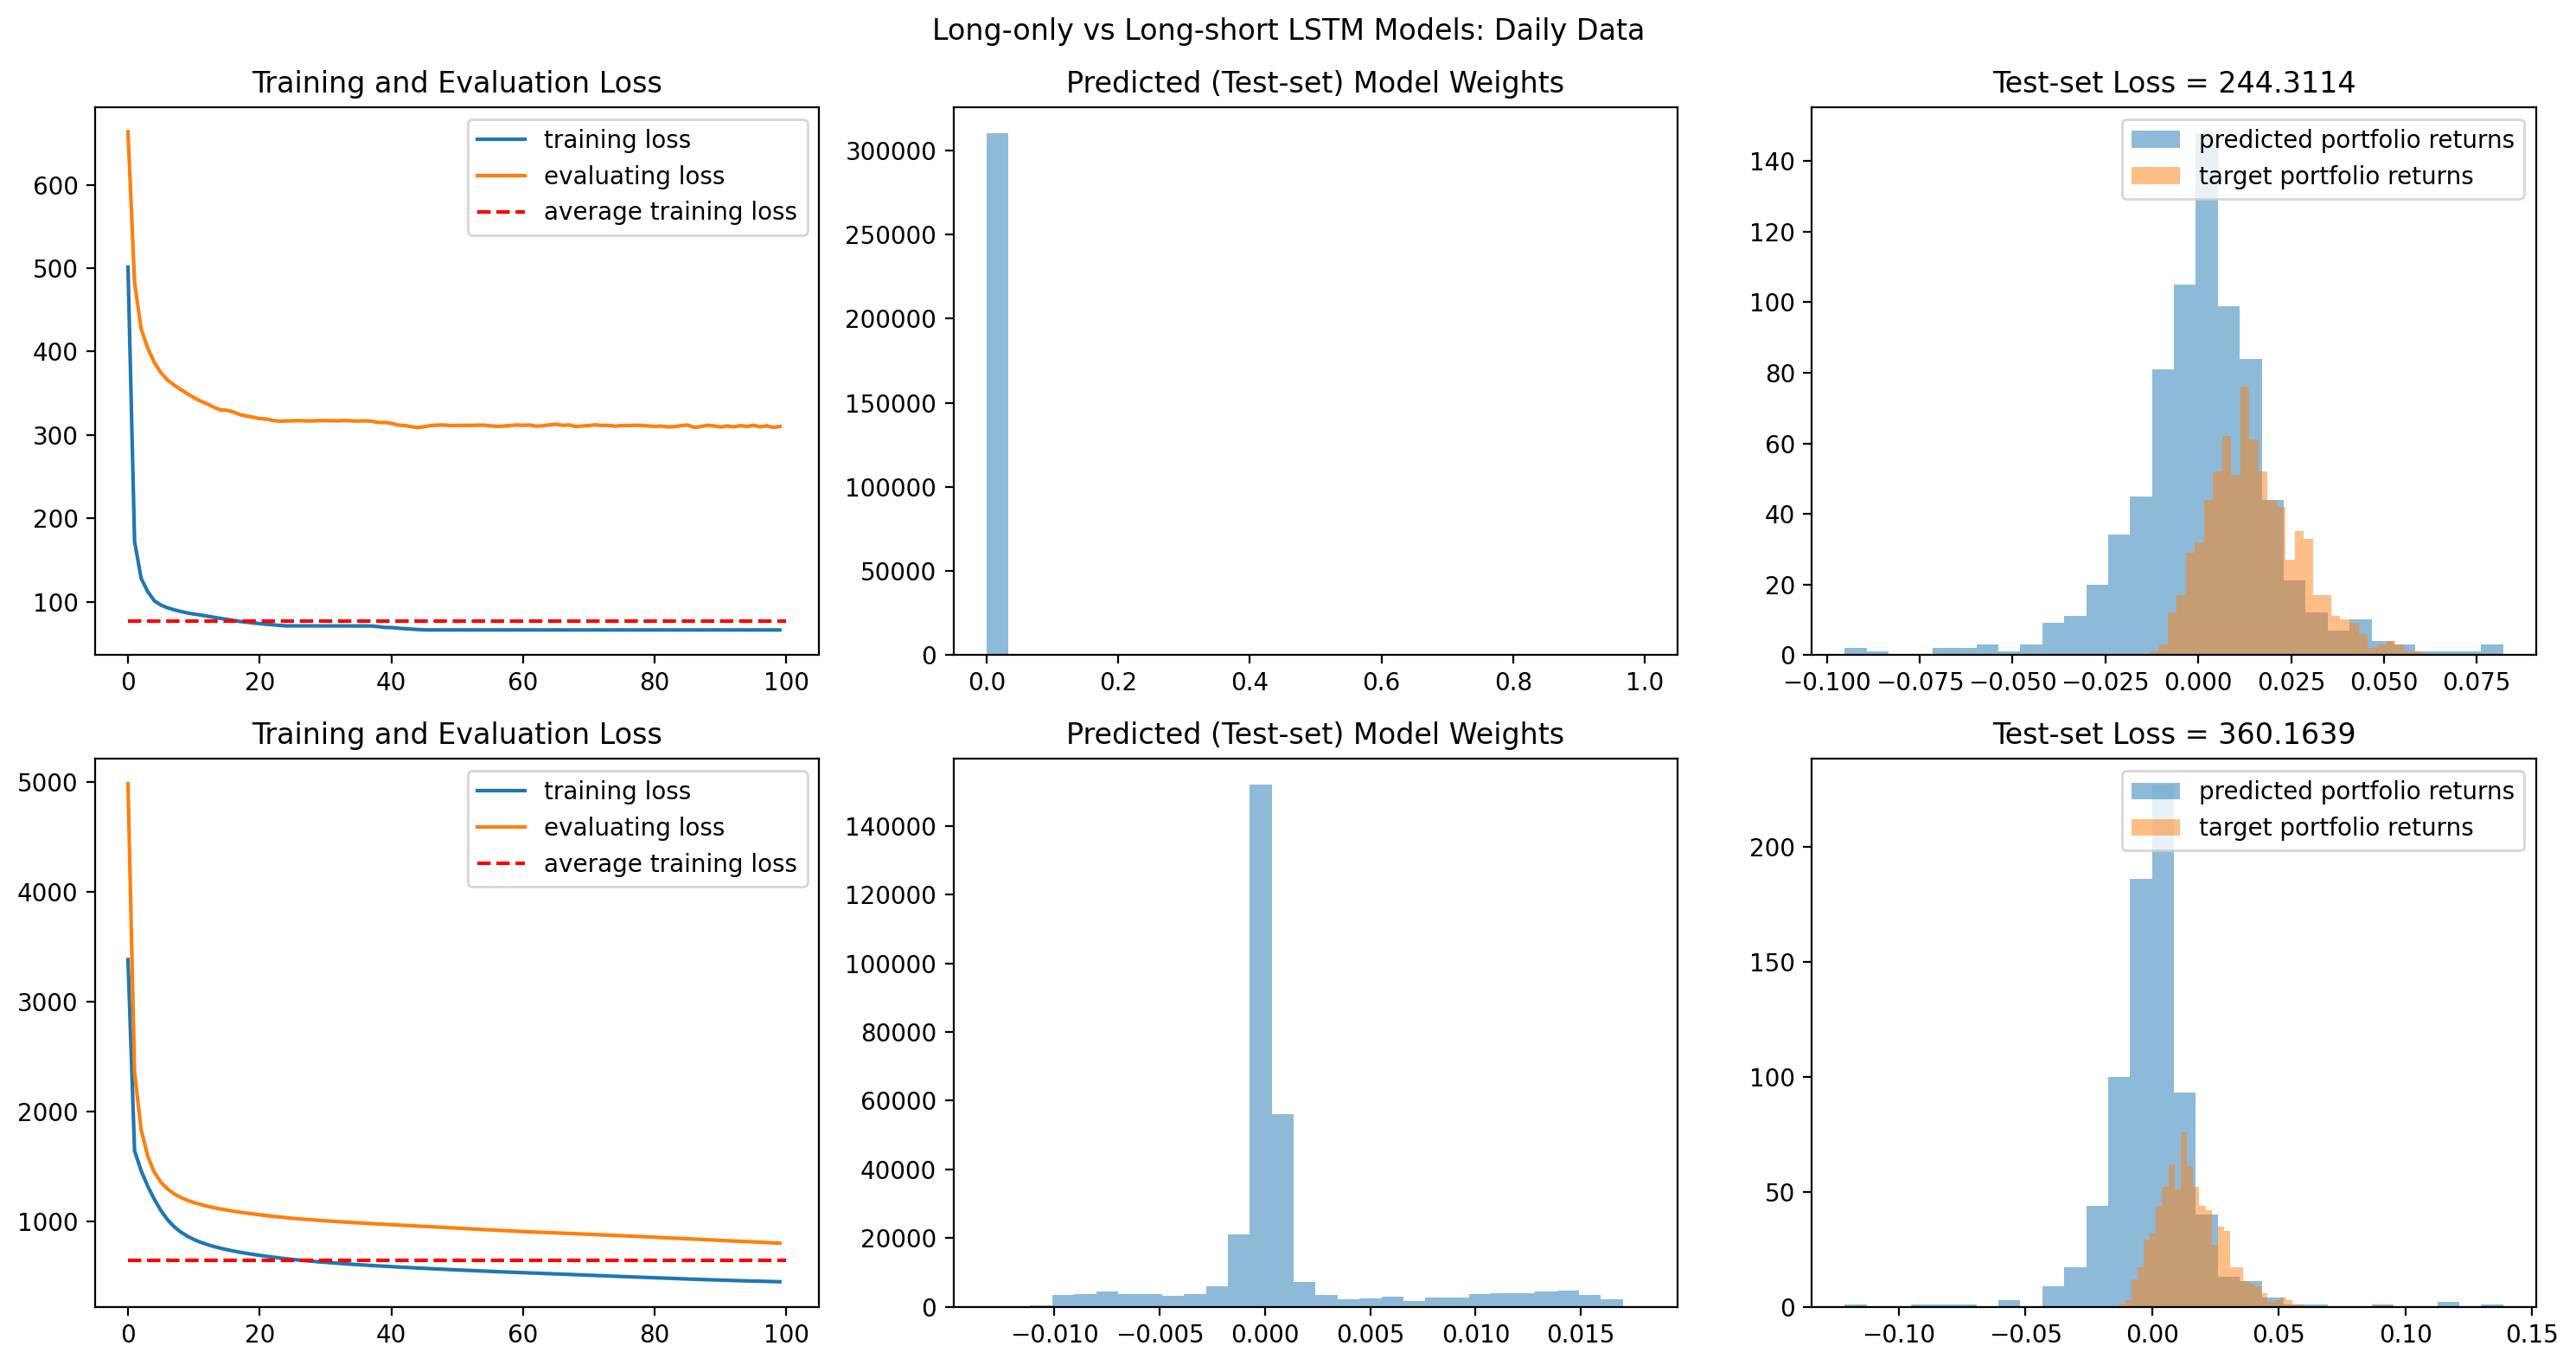

In [8]:
avg_tr_loss_l = np.mean(lstm_model_l.tr_loss_container, axis = 0)
avg_tr_loss_ls = np.mean(lstm_model_ls.tr_loss_container, axis = 0)

fig, (ax1, ax2) = plt.subplots(2, 3, figsize = (15, 8), dpi = 200)
fig.suptitle(f'Long-only vs Long-short LSTM Models: Daily Data')

# long-only model
ax1[0].set_title('Training and Evaluation Loss')
ax1[0].plot(lstm_model_l.tr_loss_container)
ax1[0].plot(lstm_model_l.eval_loss_container)
ax1[0].hlines(lstm_model_l.avg_tr_loss, 0, epochs, color = 'r', linestyle = '--')
ax1[0].legend(['training loss', 'evaluating loss', 'average training loss'])

ax1[1].set_title('Predicted (Test-set) Model Weights')
ax1[1].hist(ts_lstm_l['weights'].flatten(), alpha = 0.5, bins = 30)

ax1[2].set_title(f'Test-set Loss = {lstm_model_l.eval_loss:.4f}')
ax1[2].hist(ts_lstm_l['returns'], alpha = 0.5, bins = 30)
ax1[2].hist(y_test, alpha = 0.5, bins = 30)
ax1[2].legend(['predicted portfolio returns', 'target portfolio returns'])

# long-short model
ax2[0].set_title('Training and Evaluation Loss')
ax2[0].plot(lstm_model_ls.tr_loss_container)
ax2[0].plot(lstm_model_ls.eval_loss_container)
ax2[0].hlines(lstm_model_ls.avg_tr_loss, 0, epochs, color = 'r', linestyle = '--')
ax2[0].legend(['training loss', 'evaluating loss', 'average training loss'])

ax2[1].set_title('Predicted (Test-set) Model Weights')
ax2[1].hist(ts_lstm_ls['weights'].flatten(), histtype = 'barstacked', alpha = 0.5, bins = 30)

ax2[2].set_title(f'Test-set Loss = {lstm_model_ls.eval_loss:.4f}')
ax2[2].hist(ts_lstm_ls['returns'], alpha = 0.5, bins = 30)
ax2[2].hist(y_test, alpha = 0.5, bins = 30)
ax2[2].legend(['predicted portfolio returns', 'target portfolio returns'])

plt.tight_layout();

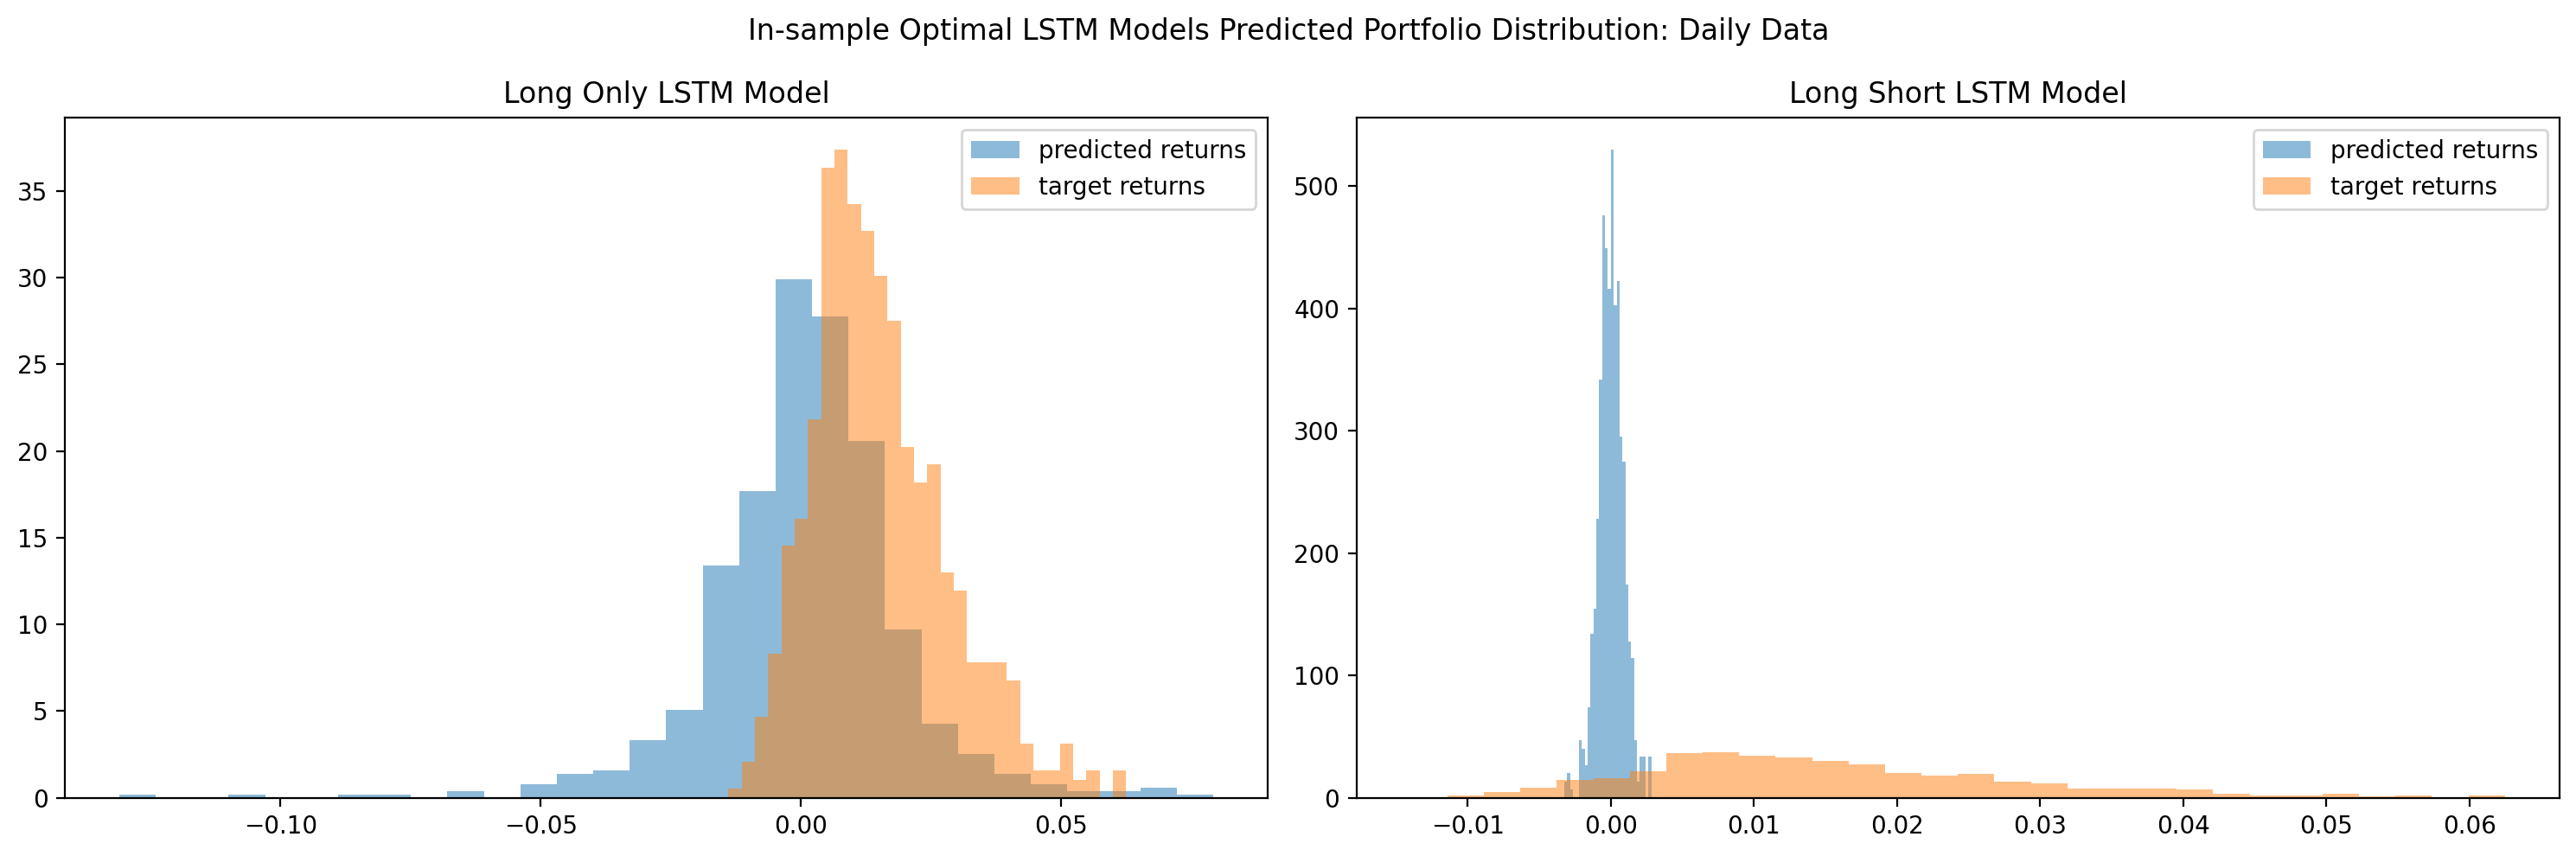

In [18]:
fig, ax1 = plt.subplots(1, 2, figsize = (15, 5), dpi = 200)
fig.suptitle(f'In-sample Optimal LSTM Models Predicted Portfolio Distribution: Daily Data')

ax1[0].set_title('Long Only LSTM Model')
ax1[0].hist(lstm_model_l.opt_res['returns'], alpha = 0.5, density = True, bins = 30)
ax1[0].hist(y_eval, alpha = 0.5, density = True, bins = 30)
ax1[0].legend(['predicted returns', 'target returns'])

ax1[1].set_title(f'Long Short LSTM Model')
ax1[1].hist(lstm_model_ls.opt_res['returns'], alpha = 0.5, density = True, bins = 30)
ax1[1].hist(y_eval, alpha = 0.5, density = True, bins = 30)
ax1[1].legend(['predicted returns', 'target returns'])

plt.tight_layout();

## **Walk Forward Multi-Processing Analysis**

In [21]:
# pull data 
with open('model_multi_processing/wfa.pkl', 'rb') as f:
   obj = pickle.load(f)

# array of individual predictions (make function that saves all returns and flattens)
lstm = obj[('lstm', False)] 
dls = obj[('lstm', True)]
nn = obj[('nn', False)]

# specific model payloads
lstm_l = lstm['long']
lstm_ls = lstm['long_short']

dls_l = dls['long']
dls_ls = dls['long_short']

nn_l = nn['long']
nn_ls = nn['long_short']

# combine payloads 
def paylaod_to_dict(model_payload):
    ws = np.ones_like(model_payload)
    rts = np.ones_like(model_payload)
    vol_scale = np.ones_like(model_payload)
    
    for idx, payload in enumerate(model_payload): 
        ws[idx] = payload['weights']
        rts[idx] = payload['returns']
        if 'vol_scale' in payload.keys():
            vol_scale[idx] = payload['vol_scale']

    # reshape
    ws = np.vstack(ws) 
    rts = np.vstack(rts).squeeze()
    vol_scale = np.vstack(vol_scale).squeeze()

    return {
        'weights': ws, 
        'returns': rts, 
        'vol_scales': vol_scale
    }

# wfa model outputs
lstm_l = paylaod_to_dict(lstm_l)
lstm_ls = paylaod_to_dict(lstm_ls)

dls_l = paylaod_to_dict(dls_l)
dls_ls = paylaod_to_dict(dls_ls)

nn_l = paylaod_to_dict(nn_l)
nn_ls = paylaod_to_dict(nn_ls)

### **Equity Performance**

In [23]:
def equity_curve(returns: np.ndarray):
    returns[0] = 0
    log_returns = np.log(1 + returns)
    sum = np.cumsum(log_returns)
    final_returns = np.exp(sum) - 1

    return final_returns

# time
wfa_time = len(lstm_l['returns'])

# benchmark
annualised_time = 24*365
wfa_returns = dataset_returns[-wfa_time: ].to_numpy()
wfa_time = dataset_returns[-wfa_time: ].index

#benchmark_weights, ef = mvo.mvo(wfa_returns, annualised_time)
#benchmark_returns = np.sum(benchmark_weights*wfa_returns, axis = 1)
#eq_benchmark = equity_curve(benchmark_returns)

# lstm model 
eq_lstm_l = equity_curve(lstm_l['returns'])
eq_lstm_ls = equity_curve(lstm_ls['returns'])
# dls
eq_dls_l = equity_curve(dls_l['returns'])
eq_dls_ls = equity_curve(dls_ls['returns'])
# nn model
eq_nn_l = equity_curve(nn_l['returns'])
eq_nn_ls = equity_curve(nn_ls['returns'])

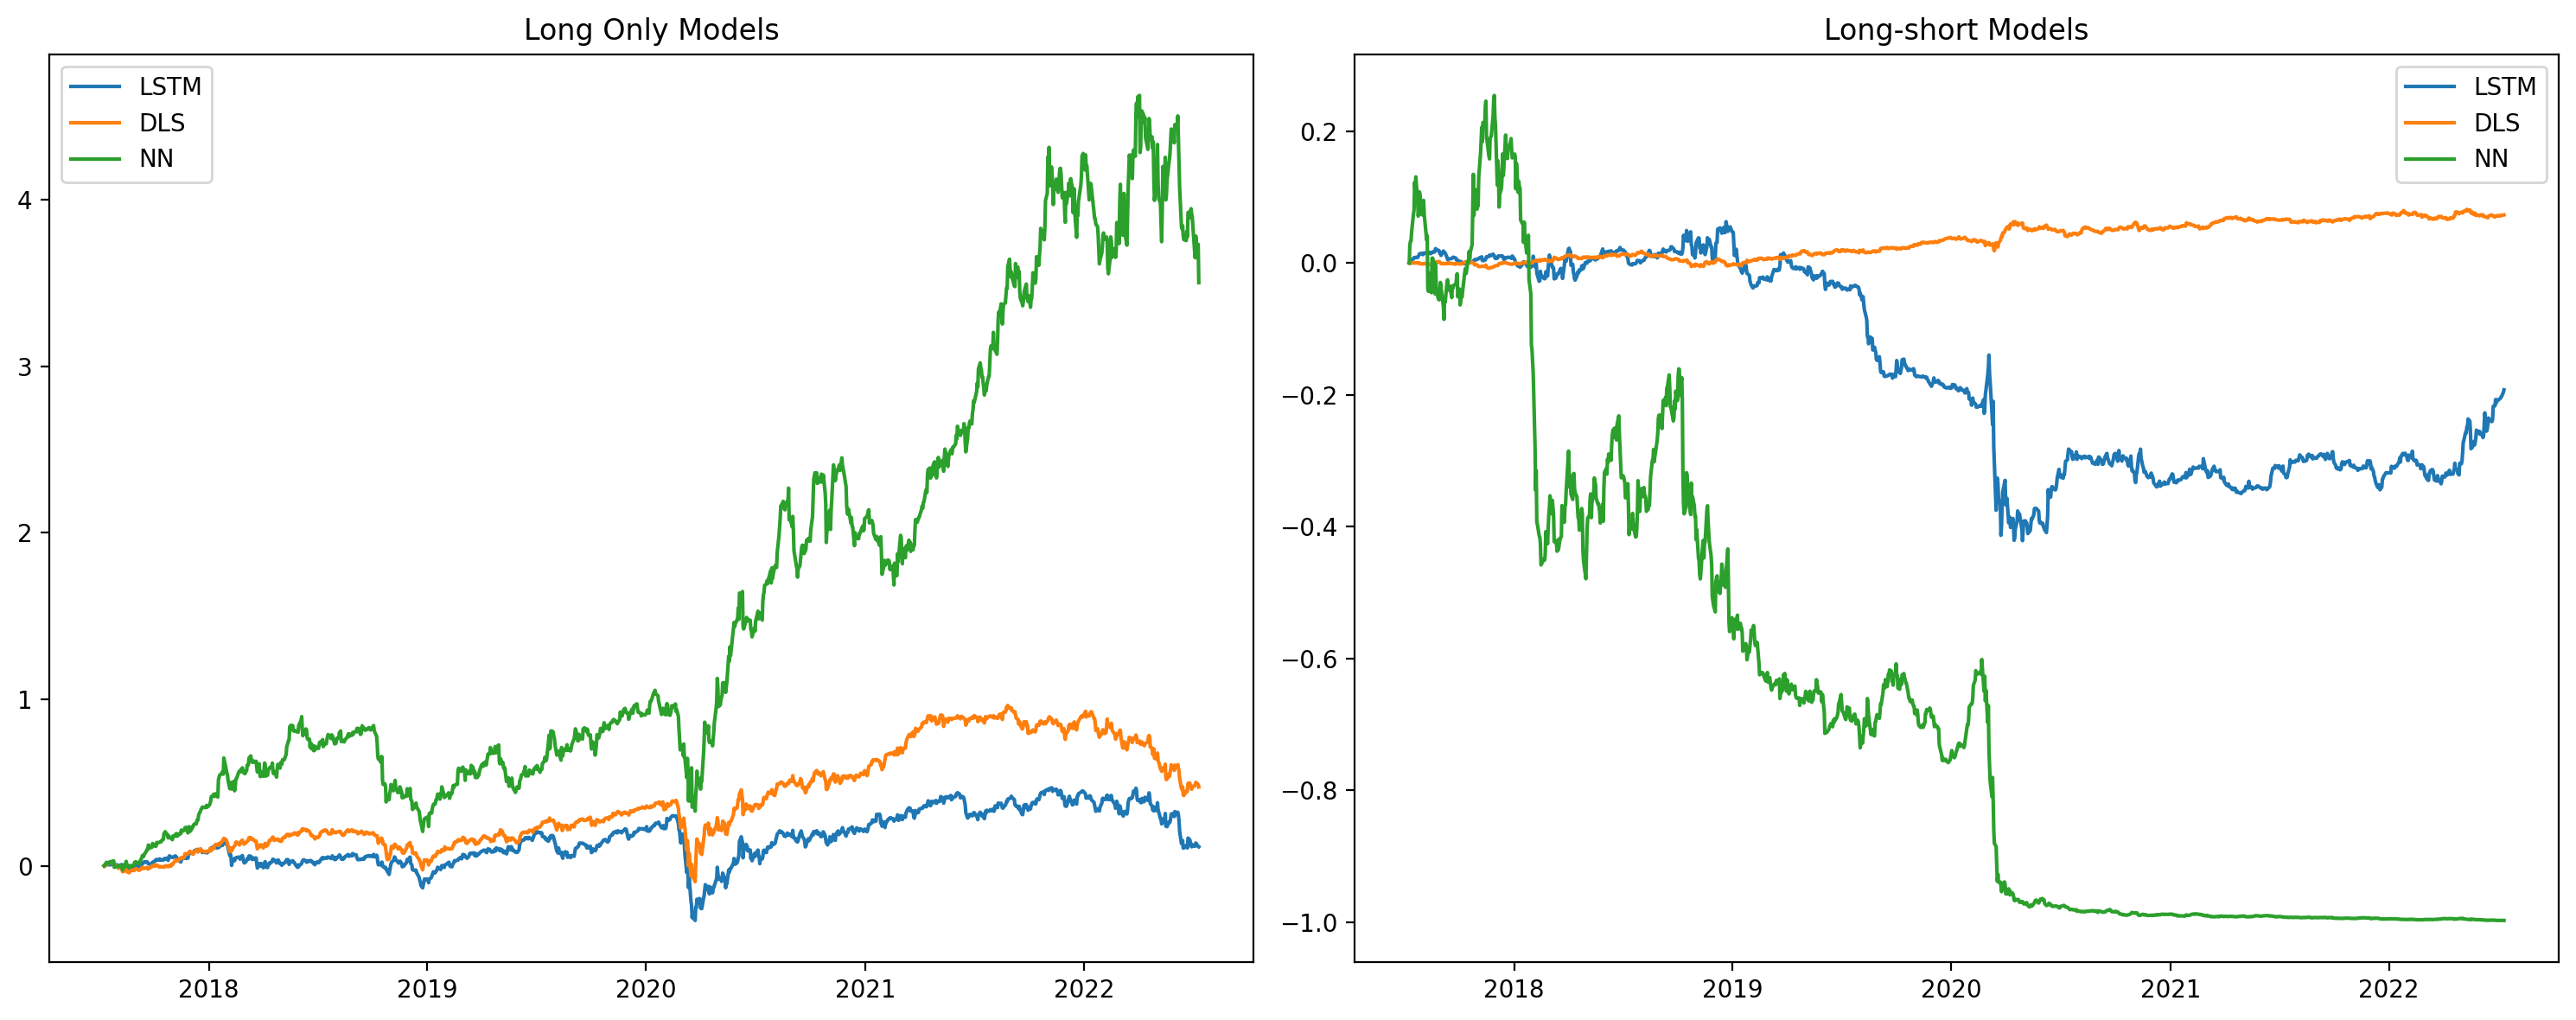

In [25]:
fig, ax1 = plt.subplots(1, 2, figsize = (15, 6), dpi = 200)
eq_keys = ['LSTM', 'DLS', 'NN']


# long only models
ax1[0].set_title('Long Only Models')
#ax1[0].plot(eq_benchmark) 
ax1[0].plot(wfa_time, eq_lstm_l) 
ax1[0].plot(wfa_time, eq_dls_l) 
ax1[0].plot(wfa_time, eq_nn_l) 
ax1[0].legend(eq_keys)

# long-short models
ax1[1].set_title('Long-short Models') 
#ax1[1].plot(eq_benchmark)
ax1[1].plot(wfa_time, eq_lstm_ls)
ax1[1].plot(wfa_time, eq_dls_ls)
ax1[1].plot(wfa_time, eq_nn_ls)
ax1[1].legend(eq_keys)

plt.tight_layout();

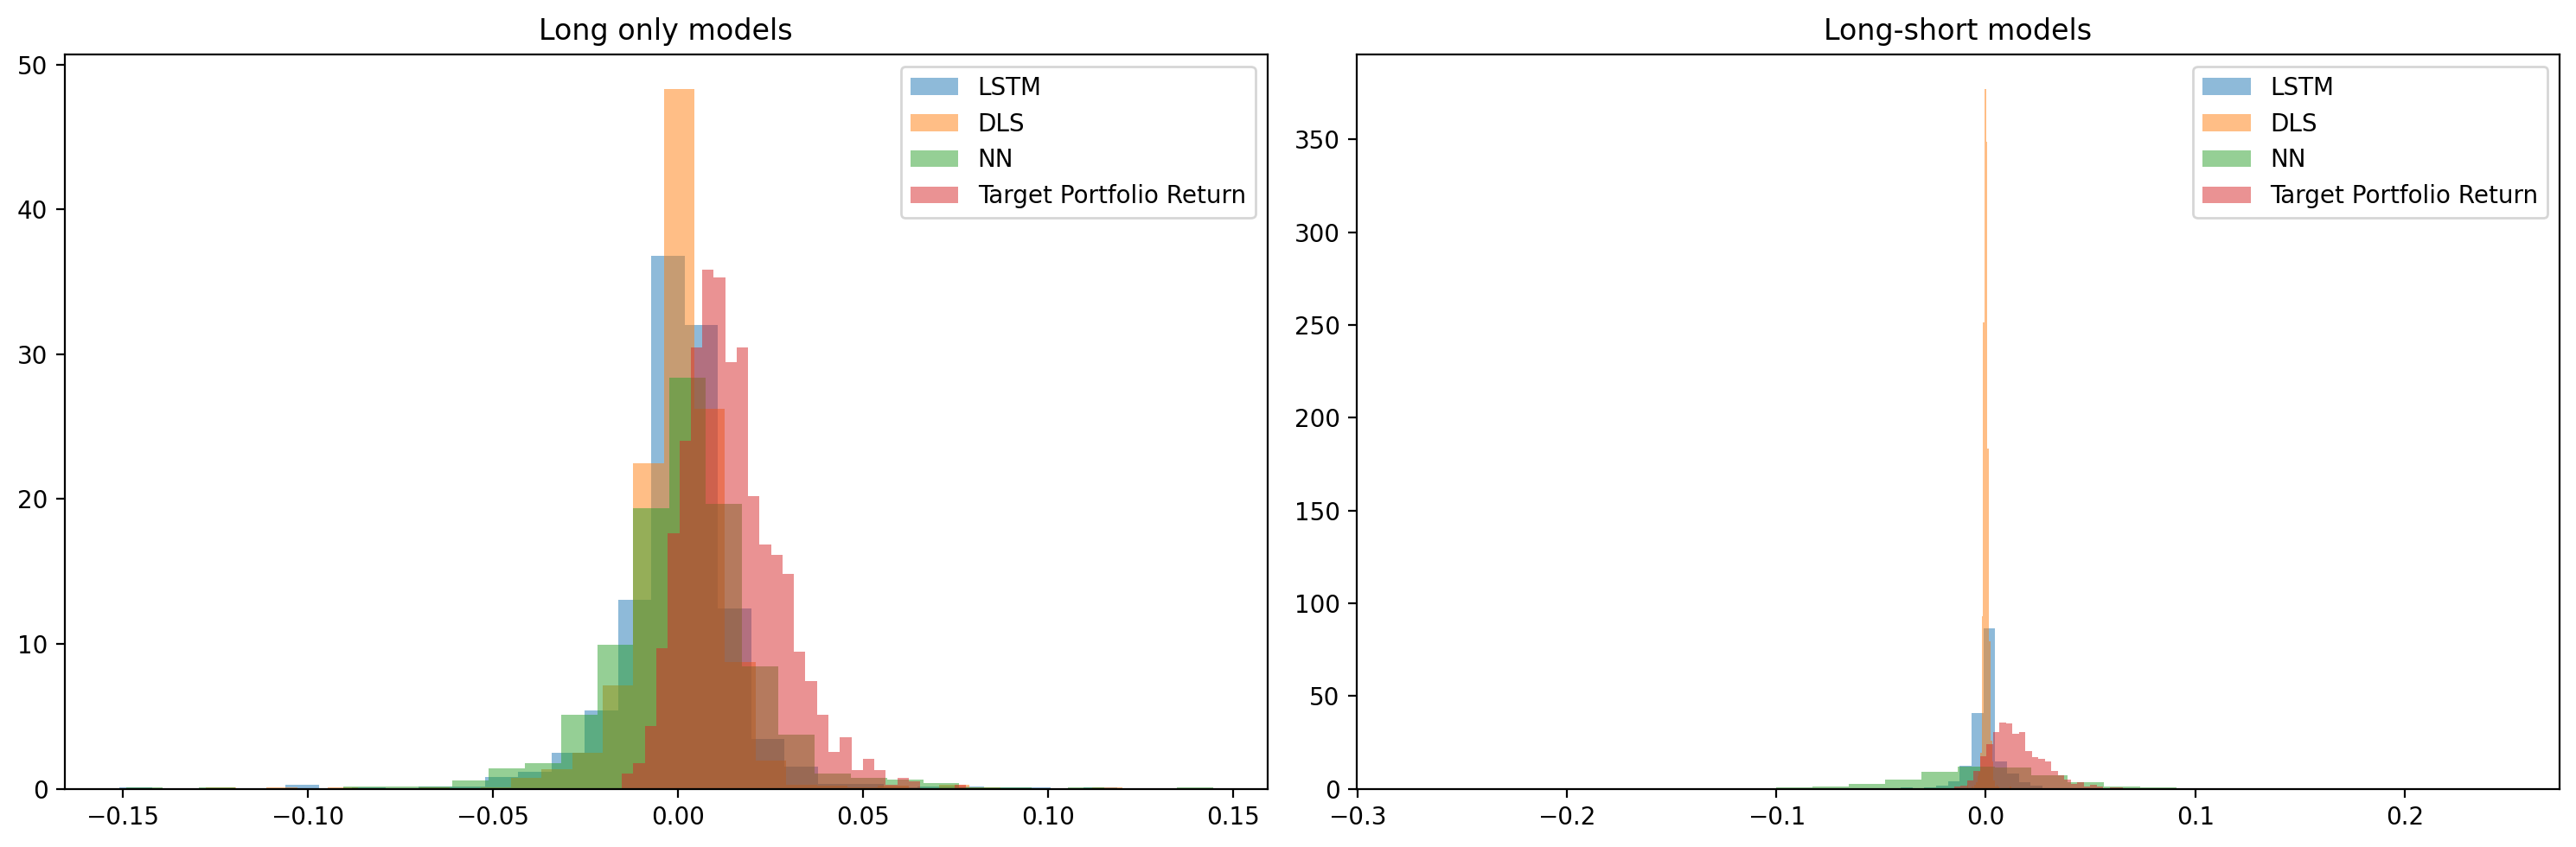

In [29]:
fig, ax1 = plt.subplots(1, 2, figsize = (15, 5), dpi = 200)

# time 
target_dist = target_returns[-len(wfa_time): ]

# long only models 
ax1[0].set_title('Long only models')
ax1[0].hist(lstm_l['returns'], alpha = 0.5, density = True, bins = 30)
ax1[0].hist(dls_l['returns'], alpha = 0.5, density = True, bins = 30) # dls modles
ax1[0].hist(nn_l['returns'], alpha = 0.5, density = True, bins = 30) # benchmarl
ax1[0].hist(target_dist, alpha = 0.5, density = True, bins = 30)

# long-short models
ax1[1].set_title('Long-short models') 
ax1[1].hist(lstm_ls['returns'], alpha = 0.5, density = True, bins = 30)
ax1[1].hist(dls_ls['returns'], alpha = 0.5, density = True, bins = 30)
ax1[1].hist(nn_ls['returns'], alpha = 0.5, density = True, bins = 30)
ax1[1].hist(target_dist, alpha = 0.5, density = True, bins = 30)

# legend
lg = ['LSTM', 'DLS', 'NN', 'Target Portfolio Return']
ax1[0].legend(lg)
ax1[1].legend(lg )

plt.tight_layout();

## **Appendix**

[1] - [Coinbase Taker/Maker Spot Fees](https://www.coinbase.com/advanced-fees) $\\$